In [ ]:
# ============================================================
# ML FOR SOCIAL GOOD - MISSION HEALTH
# Early Prediction of Diabetes Risk Using Ensemble ML
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

import shap
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


LOAD DATASET

In [ ]:
df = pd.read_csv("data/diabetes_data_upload.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (520, 17)


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [ ]:
df = pd.read_csv("data/diabetes_data_upload.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (520, 17)


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


BASIC DATA UNDERSTANDING

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 520
Columns: 17


In [ ]:
df.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [ ]:
df.describe(include="all")

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
count,520.000000,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520
unique,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,NaN,Male,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,Positive
freq,NaN,328,262,287,303,305,283,404,287,267,394,281,296,325,341,432,320
mean,48.028846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,12.151466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,47.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Polyuria,0
Polydipsia,0
sudden weight loss,0
weakness,0
Polyphagia,0
Genital thrush,0
visual blurring,0
Itching,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 269


In [ ]:
print(df["class"].value_counts())

class
Positive    320
Negative    200
Name: count, dtype: int64


In [ ]:
print(df["class"].value_counts(normalize=True) * 100)

class
Positive    61.538462
Negative    38.461538
Name: proportion, dtype: float64


DATA CLEANING

First standardize column names.

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss',
       'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring',
       'itching', 'irritability', 'delayed_healing', 'partial_paresis',
       'muscle_stiffness', 'alopecia', 'obesity', 'class'],
      dtype='object')

Remove duplicates

In [ ]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 520
Rows after: 251
Duplicates removed: 269


Check missing values


In [ ]:
missing = df.isnull().sum()

print(missing)

age                   0
gender                0
polyuria              0
polydipsia            0
sudden_weight_loss    0
weakness              0
polyphagia            0
genital_thrush        0
visual_blurring       0
itching               0
irritability          0
delayed_healing       0
partial_paresis       0
muscle_stiffness      0
alopecia              0
obesity               0
class                 0
dtype: int64


TARGET ENCODING

Positive → 1
Negative → 0

In [ ]:
df["target"] = df["class"].map({
    "Positive": 1,
    "Negative": 0
})

df["target"].value_counts()

,count
target,
1,173
0,78


Now remove original target

In [ ]:
df = df.drop(columns=["class"])

df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,target
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,1
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,1
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,1
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,1
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1


CHECK DATA TYPES

In [ ]:
df.dtypes

,0
age,int64
gender,object
polyuria,object
polydipsia,object
sudden_weight_loss,object
weakness,object
polyphagia,object
genital_thrush,object
visual_blurring,object
itching,object


We will separate:
numerical features
categorical features


In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (251, 16)
Target: (251,)


CLASS DISTRIBUTION

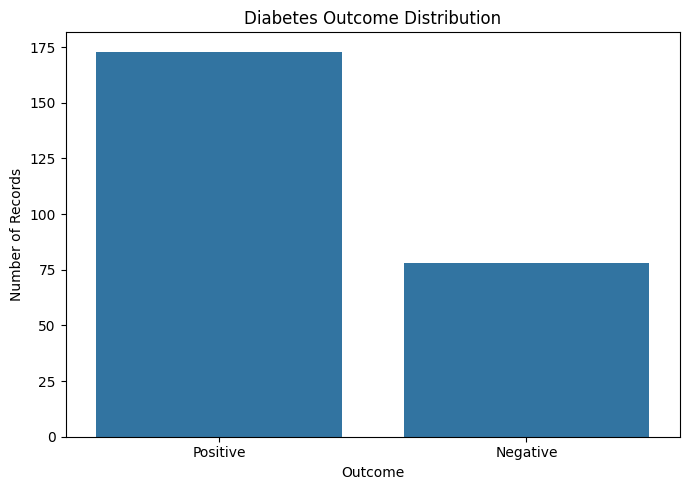

In [ ]:
import os

plt.figure(figsize=(7,5))

sns.countplot(
    x=y.map({0: "Negative", 1: "Positive"})
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Records")

plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
if not os.path.exists("figures"):
    os.makedirs("figures")

plt.savefig(
    "figures/class_distribution.png",
    dpi=300
)

plt.show()

EDA — AGE DISTRIBUTION

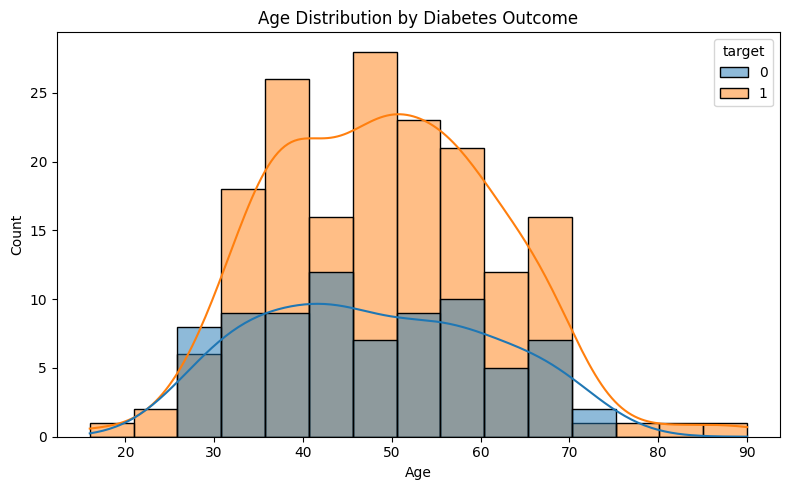

In [ ]:
import os

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="target",
    bins=15,
    kde=True
)

plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
if not os.path.exists("figures"):
    os.makedirs("figures")

plt.savefig(
    "figures/age_distribution.png",
    dpi=300
)

plt.show()

EDA — SYMPTOM ANALYSIS



Convert Yes/No to numeric temporarily for analysis.


In [ ]:
eda_df = df.copy()

binary_columns = [
    col for col in eda_df.columns
    if col not in ["age", "gender", "target"]
]

for col in binary_columns:
    eda_df[col] = eda_df[col].map({
        "Yes": 1,
        "No": 0
    })

Calculate positive outcome rate.

In [ ]:
positive_rates = {}

for col in binary_columns:
    positive_rates[col] = (
        eda_df.groupby(col)["target"]
        .mean()
        .to_dict()
    )

positive_rates

{'polyuria': {0: 0.3865546218487395, 1: 0.9621212121212122},
 'polydipsia': {0: 0.41732283464566927, 1: 0.967741935483871},
 'sudden_weight_loss': {0: 0.54421768707483, 1: 0.8942307692307693},
 'weakness': {0: 0.5978260869565217, 1: 0.7421383647798742},
 'polyphagia': {0: 0.5522388059701493, 1: 0.8461538461538461},
 'genital_thrush': {0: 0.6358695652173914, 1: 0.835820895522388},
 'visual_blurring': {0: 0.6071428571428571, 1: 0.7927927927927928},
 'itching': {0: 0.7016129032258065, 1: 0.6771653543307087},
 'irritability': {0: 0.6111111111111112, 1: 0.8873239436619719},
 'delayed_healing': {0: 0.6666666666666666, 1: 0.712},
 'partial_paresis': {0: 0.539568345323741, 1: 0.875},
 'muscle_stiffness': {0: 0.6470588235294118, 1: 0.7551020408163265},
 'alopecia': {0: 0.7577639751552795, 1: 0.5666666666666667},
 'obesity': {0: 0.6714975845410628, 1: 0.7727272727272727}}

TOP FEATURE VISUALIZATION

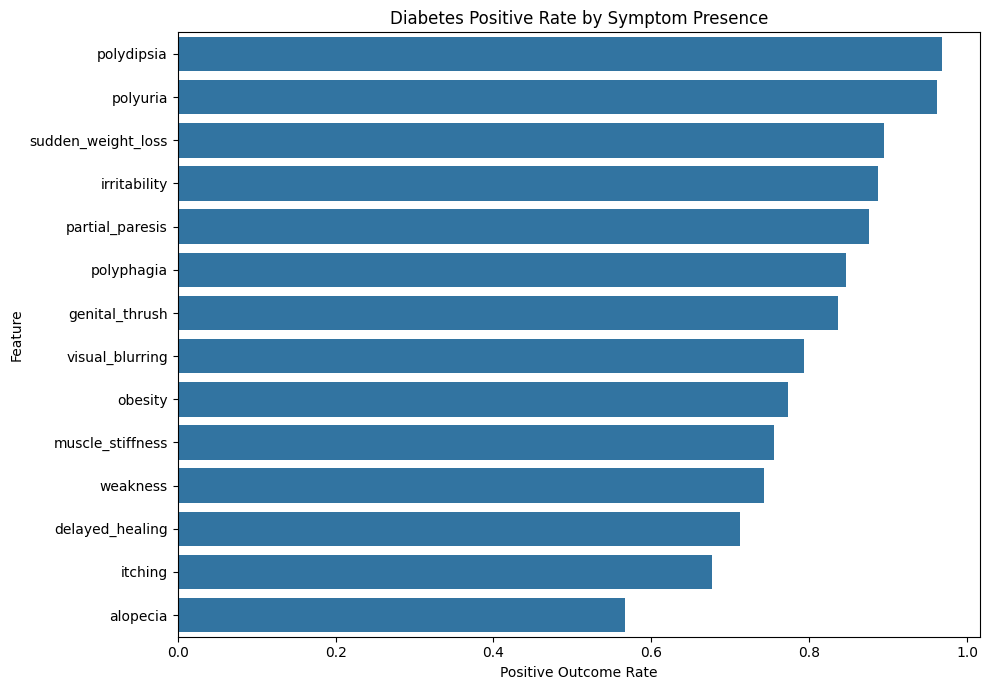

In [ ]:
feature_rates = []

for col in binary_columns:

    if eda_df[col].notna().sum() > 0:

        rate_yes = eda_df.loc[
            eda_df[col] == 1,
            "target"
        ].mean()

        feature_rates.append(
            [col, rate_yes]
        )

feature_rates_df = pd.DataFrame(
    feature_rates,
    columns=["Feature", "Positive_Rate"]
)

feature_rates_df = feature_rates_df.sort_values(
    "Positive_Rate",
    ascending=False
)

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_rates_df,
    x="Positive_Rate",
    y="Feature"
)

plt.title(
    "Diabetes Positive Rate by Symptom Presence"
)

plt.xlabel("Positive Outcome Rate")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "figures/symptom_positive_rate.png",
    dpi=300
)

plt.show()

FEATURE ENGINEERING


Create a clinically interpretable symptom burden feature.


In [ ]:
feature_cols = [
    "polyuria",
    "polydipsia",
    "sudden_weight_loss",
    "weakness",
    "polyphagia",
    "genital_thrush",
    "visual_blurring",
    "itching",
    "irritability",
    "delayed_healing",
    "partial_paresis",
    "muscle_stiffness",
    "alopecia",
    "obesity"
]

Create a count

In [ ]:
temp = X.copy()

for col in feature_cols:
    temp[col] = temp[col].map({
        "Yes": 1,
        "No": 0
    })

temp["symptom_burden"] = temp[feature_cols].sum(axis=1)

temp[[
    "symptom_burden"
]].head()

,symptom_burden
0,7
1,4
2,7
3,6
4,13


TRAIN / VALIDATION / TEST SPLIT

70% Training
15% Validation
15% Testing

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (175, 16)
Validation: (38, 16)
Testing: (38, 16)


This gives approximately

Training: 70%
Validation: 15%
Testing: 15%


IDENTIFY FEATURE TYPES

In [ ]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']
Numerical: ['age']


PREPROCESSING PIPELINE

In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

Categorical pipeline

In [ ]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

Combine

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

BASELINE — LOGISTIC REGRESSION

In [ ]:
baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model trained!")

Baseline model trained!


RANDOM FOREST — BAGGING

In [ ]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                max_depth=None
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained!")

Random Forest trained!


XGBOOST — BOOSTING

In [ ]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained!")

XGBoost trained!


MODEL EVALUATION FUNCTION


In [ ]:
def evaluate_model(model, X_data, y_data, model_name):

    predictions = model.predict(X_data)

    probabilities = model.predict_proba(
        X_data
    )[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_data,
            predictions
        ),
        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_data,
            probabilities
        )
    }

    return results

EVALUATE BASELINE

In [ ]:
baseline_results = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    "Logistic Regression"
)

baseline_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8157894736842105,
 'Precision': 1.0,
 'Recall': 0.7307692307692307,
 'F1': 0.8444444444444444,
 'ROC-AUC': np.float64(0.9423076923076923)}


EVALUATE RANDOM FOREST

In [ ]:
rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.8947368421052632,
 'Precision': 0.9230769230769231,
 'Recall': 0.9230769230769231,
 'F1': 0.9230769230769231,
 'ROC-AUC': np.float64(0.9551282051282052)}

 EVALUATE XGBOOST


In [ ]:
xgb_results = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.8947368421052632,
 'Precision': 1.0,
 'Recall': 0.8461538461538461,
 'F1': 0.9166666666666666,
 'ROC-AUC': np.float64(0.967948717948718)}

 CREATE RESULTS TABLE


In [ ]:
results = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.815789,1.000000,0.730769,0.844444,0.942308
1,Random Forest,0.894737,0.923077,0.923077,0.923077,0.955128
2,XGBoost,0.894737,1.000000,0.846154,0.916667,0.967949


In [ ]:
import os

# Create the 'results' directory if it doesn't exist
if not os.path.exists("results"):
    os.makedirs("results")

results.to_csv(
    "results/model_results.csv",
    index=False
)

HYPERPARAMETER TUNING — RANDOM FOREST


In [ ]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [ ]:
rf_params = {
    "classifier__n_estimators": [
        100,
        200,
        300
    ],
    "classifier__max_depth": [
        None,
        5,
        10
    ],
    "classifier__min_samples_split": [
        2,
        5
    ]
}

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

print("Best RF parameters:")
print(rf_grid.best_params_)

print("Best CV ROC-AUC:")
print(rf_grid.best_score_)

Best RF parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV ROC-AUC:
0.9810606060606061


 TUNED RANDOM FOREST


In [ ]:
tuned_rf = rf_grid.best_estimator_

tuned_rf_results = evaluate_model(
    tuned_rf,
    X_test,
    y_test,
    "Tuned Random Forest"
)

tuned_rf_results

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.8947368421052632,
 'Precision': 0.9230769230769231,
 'Recall': 0.9230769230769231,
 'F1': 0.9230769230769231,
 'ROC-AUC': np.float64(0.9519230769230769)}

 TUNE XGBOOST


In [ ]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                eval_metric="logloss",
                random_state=42
            )
        )
    ]
)

In [ ]:
xgb_params = {
    "classifier__n_estimators": [
        100,
        200
    ],
    "classifier__max_depth": [
        3,
        4,
        5
    ],
    "classifier__learning_rate": [
        0.03,
        0.05,
        0.1
    ]
}

In [ ]:
xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(
    X_train,
    y_train
)

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)

print(
    "Best CV ROC-AUC:",
    xgb_grid.best_score_
)

Best XGBoost parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.9727272727272727


TUNED XGBOOST RESULTS


In [ ]:
tuned_xgb = xgb_grid.best_estimator_

tuned_xgb_results = evaluate_model(
    tuned_xgb,
    X_test,
    y_test,
    "Tuned XGBoost"
)

tuned_xgb_results

{'Model': 'Tuned XGBoost',
 'Accuracy': 0.9210526315789473,
 'Precision': 1.0,
 'Recall': 0.8846153846153846,
 'F1': 0.9387755102040817,
 'ROC-AUC': np.float64(0.9647435897435898)}

 STACKING MODEL
For the heterogeneous ensemble, we'll combine different algorithms.

In [ ]:
stacking_model = StackingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        ),
        (
            "xgb",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                eval_metric="logloss",
                random_state=42
            )
        )
    ],
    final_estimator=LogisticRegression(
        max_iter=1000
    ),
    cv=5,
    stack_method="predict_proba"
)

In [ ]:
stacking_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            stacking_model
        )
    ]
)

stacking_pipeline.fit(
    X_train,
    y_train
)

print("Stacking model trained!")

Stacking model trained!


 EVALUATE STACKING


In [ ]:
stacking_results = evaluate_model(
    stacking_pipeline,
    X_test,
    y_test,
    "Stacking Ensemble"
)

stacking_results

{'Model': 'Stacking Ensemble',
 'Accuracy': 0.9210526315789473,
 'Precision': 1.0,
 'Recall': 0.8846153846153846,
 'F1': 0.9387755102040817,
 'ROC-AUC': np.float64(0.9615384615384615)}

FINAL MODEL COMPARISON


In [ ]:
final_results = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    tuned_rf_results,
    tuned_xgb_results,
    stacking_results
])

final_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.815789,1.000000,0.730769,0.844444,0.942308
1,Random Forest,0.894737,0.923077,0.923077,0.923077,0.955128
2,XGBoost,0.894737,1.000000,0.846154,0.916667,0.967949
3,Tuned Random Forest,0.894737,0.923077,0.923077,0.923077,0.951923
4,Tuned XGBoost,0.921053,1.000000,0.884615,0.938776,0.964744
5,Stacking Ensemble,0.921053,1.000000,0.884615,0.938776,0.961538


In [ ]:
final_results.to_csv(
    "results/final_model_comparison.csv",
    index=False
)

MODEL COMPARISON GRAPH


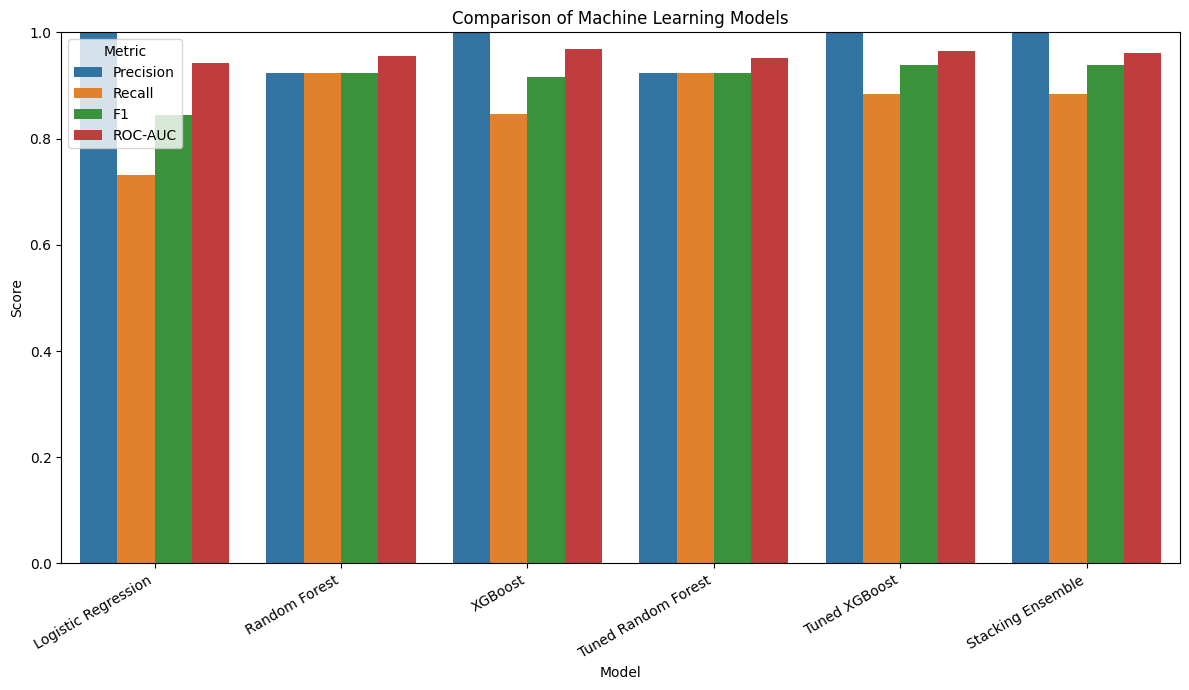

In [ ]:
plot_df = final_results.melt(
    id_vars="Model",
    value_vars=[
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(0, 1)

plt.title(
    "Comparison of Machine Learning Models"
)

plt.tight_layout()

plt.savefig(
    "figures/model_comparison.png",
    dpi=300
)

plt.show()


FIND BEST MODEL

In [ ]:
best_model_name = final_results.loc[
    final_results["ROC-AUC"].idxmax(),
    "Model"
]

best_model_name

'XGBoost'

 CONFUSION MATRIX
Let's use the stacking model for the demonstration. If another model has the best ROC-AUC, use that model instead.


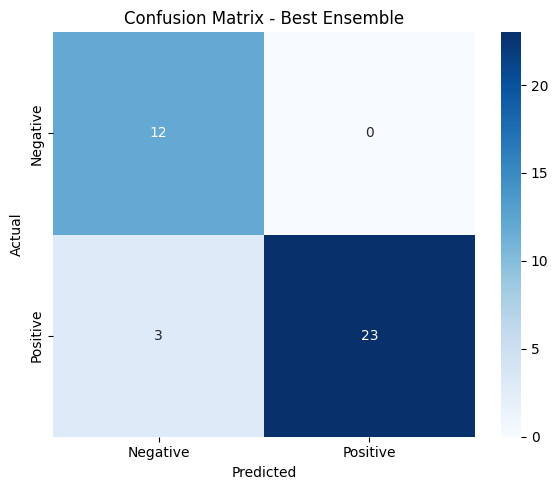

In [ ]:
best_model = stacking_pipeline

y_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.title(
    "Confusion Matrix - Best Ensemble"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "figures/confusion_matrix.png",
    dpi=300
)

plt.show()

CLASSIFICATION REPORT


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.80      1.00      0.89        12
    Positive       1.00      0.88      0.94        26

    accuracy                           0.92        38
   macro avg       0.90      0.94      0.91        38
weighted avg       0.94      0.92      0.92        38



 ROC CURVE


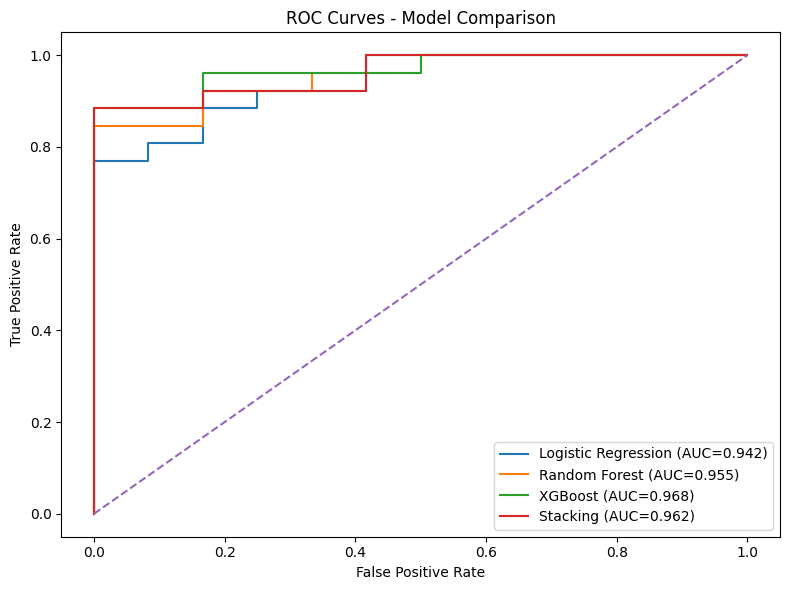

In [ ]:
models_for_roc = {
    "Logistic Regression": baseline_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Stacking": stacking_pipeline
}

plt.figure(figsize=(8,6))

for name, model in models_for_roc.items():

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves - Model Comparison"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/roc_curves.png",
    dpi=300
)

plt.show()

 CROSS-VALIDATION


In [ ]:
cv_scores = cross_val_score(
    stacking_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-validation ROC-AUC scores:")
print(cv_scores)

print(
    "Mean CV ROC-AUC:",
    cv_scores.mean()
)

print(
    "Standard deviation:",
    cv_scores.std()
)

Cross-validation ROC-AUC scores:
[0.96969697 0.97727273 0.99242424 0.9469697  1.        ]
Mean CV ROC-AUC: 0.9772727272727273
Standard deviation: 0.01855674047563013


 SAVE BEST MODEL


In [ ]:
import os

# Create the 'models' directory if it doesn't exist
if not os.path.exists("models"):
    os.makedirs("models")

joblib.dump(
    best_model,
    "models/best_diabetes_ensemble.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


 SHAP EXPLAINABILITY


In [ ]:
preprocessor_fitted = best_model.named_steps[
    "preprocessor"
]

classifier_fitted = best_model.named_steps[
    "classifier"
]

X_test_transformed = (
    preprocessor_fitted.transform(
        X_test
    )
)

print(
    X_test_transformed.shape
)

(38, 31)


In [ ]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

print(feature_names)

['numeric__age' 'categorical__gender_Female' 'categorical__gender_Male'
 'categorical__polyuria_No' 'categorical__polyuria_Yes'
 'categorical__polydipsia_No' 'categorical__polydipsia_Yes'
 'categorical__sudden_weight_loss_No'
 'categorical__sudden_weight_loss_Yes' 'categorical__weakness_No'
 'categorical__weakness_Yes' 'categorical__polyphagia_No'
 'categorical__polyphagia_Yes' 'categorical__genital_thrush_No'
 'categorical__genital_thrush_Yes' 'categorical__visual_blurring_No'
 'categorical__visual_blurring_Yes' 'categorical__itching_No'
 'categorical__itching_Yes' 'categorical__irritability_No'
 'categorical__irritability_Yes' 'categorical__delayed_healing_No'
 'categorical__delayed_healing_Yes' 'categorical__partial_paresis_No'
 'categorical__partial_paresis_Yes' 'categorical__muscle_stiffness_No'
 'categorical__muscle_stiffness_Yes' 'categorical__alopecia_No'
 'categorical__alopecia_Yes' 'categorical__obesity_No'
 'categorical__obesity_Yes']


 SHAP EXPLAINER
Because our stacking classifier is more complex, a model-agnostic SHAP explainer is appropriate.

In [ ]:
background = X_test_transformed[:50]

explainer = shap.Explainer(
    classifier_fitted.predict_proba,
    background
)

shap_values = explainer(
    X_test_transformed[:50]
)

print("SHAP explanation generated!")

PermutationExplainer explainer: 39it [00:14,  1.07it/s]

SHAP explanation generated!


 SHAP SUMMARY

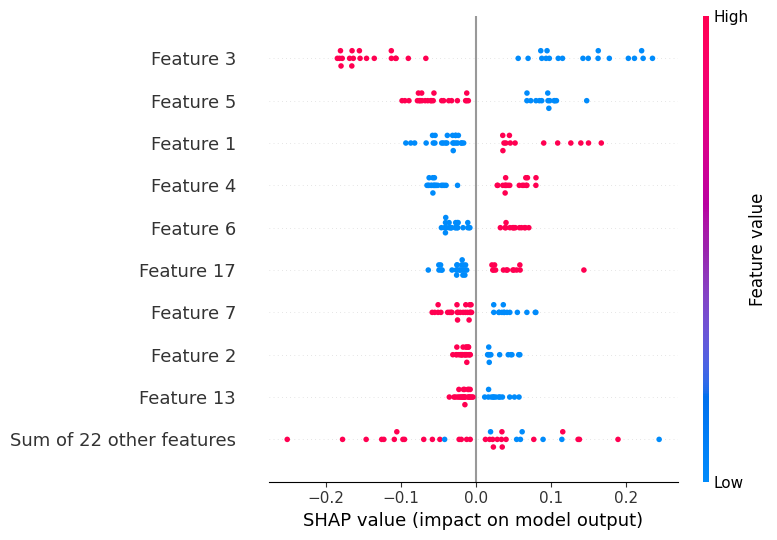

In [ ]:
shap.plots.beeswarm(
    shap_values[:, :, 1],
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

INDIVIDUAL SHAP EXPLANATION

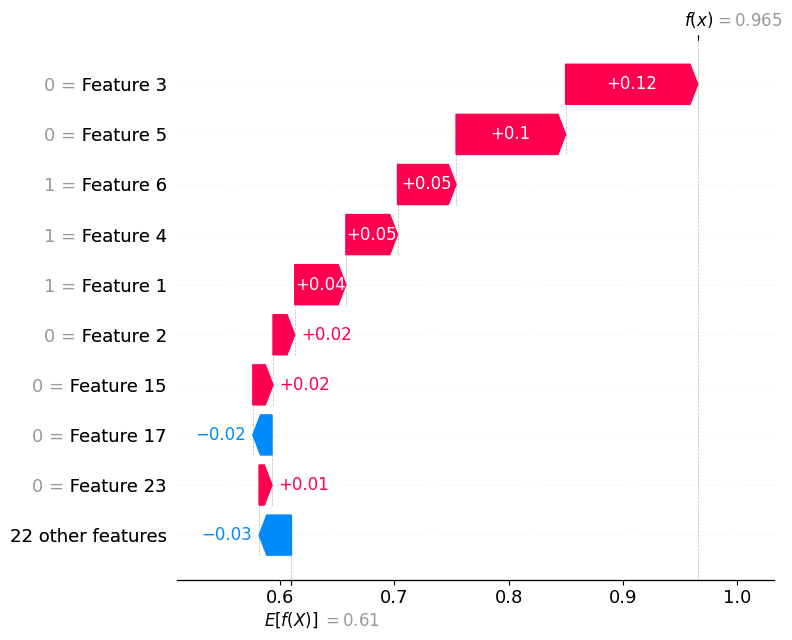

In [ ]:
sample_index = 0

shap.plots.waterfall(
    shap_values[
        sample_index,
        :,
        1
    ],
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_individual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

LIVE DEMONSTRATION
We will create a synthetic record, not a real patient.

In [ ]:
synthetic_patient = pd.DataFrame({
    "age": [52],
    "gender": ["Female"],
    "polyuria": ["Yes"],
    "polydipsia": ["Yes"],
    "sudden_weight_loss": ["No"],
    "weakness": ["Yes"],
    "polyphagia": ["Yes"],
    "genital_thrush": ["No"],
    "visual_blurring": ["Yes"],
    "itching": ["No"],
    "irritability": ["Yes"],
    "delayed_healing": ["Yes"],
    "partial_paresis": ["No"],
    "muscle_stiffness": ["No"],
    "alopecia": ["No"],
    "obesity": ["Yes"]
})

synthetic_patient

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity
0,52,Female,Yes,Yes,No,Yes,Yes,No,Yes,No,Yes,Yes,No,No,No,Yes


 PREDICTION

In [ ]:
prediction = best_model.predict(
    synthetic_patient
)[0]

probability = best_model.predict_proba(
    synthetic_patient
)[0, 1]

print(
    "Predicted class:",
    "Positive" if prediction == 1 else "Negative"
)

print(
    f"Predicted probability: {probability:.2%}"
)

Predicted class: Positive
Predicted probability: 96.40%


 DISPLAY RESULT

In [ ]:
if probability >= 0.5:

    print(
        "⚠️ Higher predicted diabetes risk"
    )

else:

    print(
        "✅ Lower predicted diabetes risk"
    )

print(
    "\nIMPORTANT: This is an educational "
    "machine-learning prediction and is not "
    "a medical diagnosis."
)

⚠️ Higher predicted diabetes risk

IMPORTANT: This is an educational machine-learning prediction and is not a medical diagnosis.


 SAVE PREDICTION


In [ ]:
prediction_output = synthetic_patient.copy()

prediction_output["predicted_class"] = (
    "Positive"
    if prediction == 1
    else "Negative"
)

prediction_output["predicted_probability"] = (
    probability
)

prediction_output.to_csv(
    "results/synthetic_prediction.csv",
    index=False
)

prediction_output

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,predicted_class,predicted_probability
0,52,Female,Yes,Yes,No,Yes,Yes,No,Yes,No,Yes,Yes,No,No,No,Yes,Positive,0.964003
